Ноутбук загружает данные, вызывает функции из `src/` и показывает результаты.
Вся вычислительная логика лежит в модулях, чтобы результат не зависел от
порядка запуска ячеек.

Параметры анализа задаются в `config.py` (`N_BOOT`, пороги отбора моделей, пути)

## 1. Настройка

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

In [3]:
# Ноутбук лежит в notebooks/, модули — в корне репозитория
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Импорты из репозитория — только после того, как путь добавлен
import config
from src import (chao_zelterman, data_io, descriptives, loglinear,
                 pipeline, plots, triangulation)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"источники: {config.SOURCE_VARS}")
print(f"ковариаты: {config.COVARIATE_VARS}")
print(f"бутстреп-итераций = {config.N_BOOT}")

источники: ['КС', 'НП', 'ПО']
ковариаты: ['sex', 'age']
бутстреп-итераций = 1000


## 2. Загружаем таблицы сопряженности

In [2]:
raw_tables = data_io.load_contingency_tables()
print(f"строк: {len(raw_tables)}, сезонов: {raw_tables['season'].nunique()}, "
      f"страт: {raw_tables['strata'].nunique()}")
raw_tables.head()

строк: 336, сезонов: 7, страт: 6


,season,strata,sex,age,КС,НП,ПО,count
0,2019/2020,"Женщины, 18‒34",Женщины,18‒34,0,0,0,0
1,2019/2020,"Женщины, 18‒34",Женщины,18‒34,0,0,1,11
2,2019/2020,"Женщины, 18‒34",Женщины,18‒34,0,1,0,9
3,2019/2020,"Женщины, 18‒34",Женщины,18‒34,0,1,1,1
4,2019/2020,"Женщины, 18‒34",Женщины,18‒34,1,0,0,17


## 3. Предварительный анализ данных

In [3]:
df_metrics = descriptives.all_strata_metrics(raw_tables)
data_io.save_table(df_metrics, config.STRATA_METRICS)
descriptives.format_metrics(df_metrics)

сохранено: data\interim\strata_metrics.csv  (42 строк)


,season,strata,n,f1,f2,f3,f1_share,f1_f2,КС_n,КС_share,НП_n,НП_share,ПО_n,ПО_share,КС_НП,КС_НП_ovl,КС_ПО,КС_ПО_ovl,НП_ПО,НП_ПО_ovl
0,2019/2020,"Женщины, 18‒34",46,37,6,3,0.80,6.17,25,0.54,13,0.28,20,0.43,3.0,0.23,8.0,0.40,4.0,0.31
1,2019/2020,"Женщины, 35‒49",86,65,18,3,0.76,3.61,49,0.57,29,0.34,32,0.37,10.0,0.34,9.0,0.28,8.0,0.28
2,2019/2020,"Женщины, 50‒79",96,72,19,5,0.75,3.79,62,0.65,32,0.33,31,0.32,15.0,0.47,9.0,0.29,10.0,0.32
3,2019/2020,"Мужчины, 18‒34",325,244,67,14,0.75,3.64,181,0.56,97,0.30,142,0.44,38.0,0.39,48.0,0.34,23.0,0.24
4,2019/2020,"Мужчины, 35‒49",626,490,112,24,0.78,4.38,326,0.52,192,0.31,268,0.43,53.0,0.28,83.0,0.31,48.0,0.25
5,2019/2020,"Мужчины, 50‒79",455,354,80,21,0.78,4.43,290,0.64,146,0.32,141,0.31,65.0,0.45,46.0,0.33,32.0,0.23
6,2020/2021,"Женщины, 18‒34",39,27,9,3,0.69,3.00,18,0.46,17,0.44,19,0.49,8.0,0.47,6.0,0.33,4.0,0.24
7,2020/2021,"Женщины, 35‒49",81,62,17,2,0.77,3.65,47,0.58,26,0.32,29,0.36,9.0,0.35,8.0,0.28,6.0,0.23
8,2020/2021,"Женщины, 50‒79",74,52,21,1,0.70,2.48,49,0.66,31,0.42,17,0.23,15.0,0.48,7.0,0.41,2.0,0.12
9,2020/2021,"Мужчины, 18‒34",262,212,38,12,0.81,5.58,118,0.45,80,0.31,126,0.48,21.0,0.26,35.0,0.30,18.0,0.23


In [4]:
descriptives.metrics_summary(df_metrics)

,n,f1_share,f1_f2,КС_share,НП_share,ПО_share,КС_НП,КС_ПО,НП_ПО
mean,231,0.77,4.48,0.56,0.31,0.40,24.76,28.40,16.93
min,24,0.68,2.38,0.39,0.21,0.23,3.00,1.00,1.00
25%,69,0.75,3.66,0.51,0.27,0.34,10.00,6.25,4.00
50%,118,0.78,4.26,0.57,0.30,0.39,15.50,16.50,11.00
75%,421,0.80,4.78,0.60,0.34,0.46,40.50,48.00,28.50
max,636,0.87,12.20,0.72,0.58,0.55,70.00,95.00,62.00


## 4. Лог-линейные модели

In [5]:
loglin = pipeline.run_loglinear(raw_tables, n_boot=config.N_BOOT, verbose=True)

data_io.save_table(loglin["models"], config.LOGLIN_MODEL_SUMMARY)
data_io.save_table(loglin["coefficients"], config.LOGLIN_COEFFICIENTS)
data_io.save_table(loglin["top_models"], config.LOGLIN_TOP_MODELS)

сезоны:   0%|          | 0/7 [00:00<?, ?it/s]


=== сезон 2019/2020 ===


  перебор моделей:   0%|          | 0/1024 [00:00<?, ?it/s]

  наблюдаемых ячеек: 42
  формул сгенерировано: 1024, подогнано: 1024
  после фильтров: 827
  наблюдаемая численность: 1634


  бутстреп:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  наблюдаемых ячеек: 42
  формул сгенерировано: 1024, подогнано: 1024
  после фильтров: 690
  наблюдаемая численность: 1124


  бутстреп:   0%|          | 0/1000 [00:00<?, ?it/s]

  loglin_saturated     est=   6016 [3788, 10384]  BIC=  -70.2
    main + [КС:НП][КС:ПО][НП:ПО][НП:В][ПО:П][ПО:В]


  бутстреп:   0%|          | 0/1000 [00:00<?, ?it/s]

  loglin_nonsaturated  est=   2583 [2276, 2946]  BIC=  -59.4
    main + [КС:НП][НП:В][ПО:П][ПО:В]
сохранено: data\interim\loglinear_model_summary.csv  (14 строк)
сохранено: data\interim\loglinear_coefficients.csv  (195 строк)
сохранено: data\interim\loglinear_top_models.csv  (42 строк)


In [6]:
# Подробнее про топ-3 модели каждого класса на сезон
for season, block in loglin["top_models"].groupby("season", sort=True):
    print(f"сезон {season}")
    display(block.drop(columns="season").set_index(["class", "rank"]))

сезон 2019/2020


модель   BIC    AIC   dev    df     k  dev/df  скрытых  оценка  охват,%
class        rank                                                                                                         
насыщенные   1           [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В] -69.8  260.5  34.8  28.0  14.0     1.2     5249    6883     23.7
             2     [КС:НП][КС:ПО][НП:ПО][КС:В][ПО:В][П:В] -69.3  257.5  27.8  26.0  16.0     1.1     5249    6883     23.7
             3                [КС:НП][КС:ПО][НП:ПО][ПО:В] -69.2  264.6  43.0  30.0  12.0     1.4     5249    6883     23.7
ненасыщенные 1                  [КС:НП][НП:ПО][ПО:В][П:В] -46.1  286.0  62.3  29.0  13.0     2.1     1741    3375     48.4
             2                       [КС:НП][НП:ПО][ПО:В] -45.4  290.1  70.4  31.0  11.0     2.3     1741    3375     48.4
             3            [КС:НП][НП:ПО][КС:В][ПО:В][П:В] -44.7  283.9  56.2  27.0  15.0     2.1     1713    3347     48.8

сезон 2020/2021


модель   BIC    AIC   dev    df     k  dev/df  скрытых  оценка  охват,%
class        rank                                                                                                          
насыщенные   1           [КС:НП][КС:ПО][НП:ПО][КС:В][ПО:П] -59.4  267.5  49.0  29.0  13.0     1.7     5663    7080     20.0
             2     [КС:НП][КС:ПО][НП:ПО][КС:П][КС:В][НП:П] -58.1  267.1  46.5  28.0  14.0     1.7     5663    7080     20.0
             3     [КС:НП][КС:ПО][НП:ПО][КС:В][НП:П][ПО:П] -57.7  267.5  46.9  28.0  14.0     1.7     5663    7080     20.0
ненасыщенные 1                  [КС:НП][НП:ПО][КС:В][ПО:П] -34.0  294.7  78.2  30.0  12.0     2.6     1710    3127     45.3
             2            [КС:НП][НП:ПО][КС:П][КС:В][НП:П] -32.7  294.3  75.7  29.0  13.0     2.6     1710    3127     45.3
             3            [КС:НП][НП:ПО][КС:В][НП:П][ПО:П] -32.3  294.6  76.1  29.0  13.0     2.6     1710    3127     45.3

сезон 2021/2022


...

модель   BIC    AIC   dev    df     k  dev/df  скрытых  оценка  охват,%
class        rank                                                                                                                
насыщенные   1           [КС:НП][КС:ПО][НП:ПО][КС:П][КС:В][ПО:В] -83.8  230.4  17.1  27.0  15.0     0.6     3385    4606     26.5
             2     [КС:НП][КС:ПО][НП:ПО][КС:П][КС:В][НП:П][ПО:В] -81.8  230.6  15.3  26.0  16.0     0.6     3385    4606     26.5
             3     [КС:НП][КС:ПО][НП:ПО][КС:П][КС:В][ПО:П][ПО:В] -81.7  230.8  15.5  26.0  16.0     0.6     3385    4606     26.5
ненасыщенные 1                  [КС:НП][КС:ПО][КС:П][КС:В][ПО:В] -77.2  238.7  27.4  28.0  14.0     1.0     1654    2875     42.5
             2                  [КС:НП][КС:ПО][КС:П][НП:В][ПО:В] -76.0  240.0  28.7  28.0  14.0     1.0     1755    2976     41.0
             3            [КС:НП][КС:ПО][КС:П][КС:В][НП:П][ПО:В] -75.2  238.9  25.7  27.0  15.0     1.0     1654    2875     42.5

сезон 2024/2025


модель   BIC    AIC   dev    df     k  dev/df  скрытых  оценка  охват,%
class        rank                                                                                                          
насыщенные   1     [КС:НП][КС:ПО][НП:ПО][КС:П][НП:В][ПО:В] -61.9  252.4  39.1  27.0  15.0     1.4     4066    5344     23.9
             2      [КС:НП][КС:ПО][НП:ПО][НП:В][ПО:В][П:В] -61.7  250.8  35.5  26.0  16.0     1.4     4066    5344     23.9
             3           [КС:НП][КС:ПО][НП:ПО][НП:В][ПО:В] -61.6  254.4  43.0  28.0  14.0     1.5     4066    5344     23.9
ненасыщенные 1            [КС:НП][КС:ПО][КС:П][НП:В][ПО:В] -60.2  255.8  44.4  28.0  14.0     1.6     2407    3685     34.7
             2             [КС:НП][КС:ПО][НП:В][ПО:В][П:В] -60.1  254.2  40.8  27.0  15.0     1.5     2407    3685     34.7
             3                  [КС:НП][КС:ПО][НП:В][ПО:В] -60.0  257.7  48.4  29.0  13.0     1.7     2407    3685     34.7

сезон 2025/2026


модель   BIC    AIC   dev    df     k  dev/df  скрытых  оценка  охват,%
class        rank                                                                                                               
насыщенные   1          [КС:НП][КС:ПО][НП:ПО][НП:В][ПО:П][ПО:В] -70.2  233.3  30.7  27.0  15.0     1.1     4892    6016     18.7
             2                [КС:НП][КС:ПО][НП:ПО][ПО:П][ПО:В] -69.0  237.9  39.4  29.0  13.0     1.4     4892    6016     18.7
             3     [КС:НП][КС:ПО][НП:ПО][НП:В][ПО:П][ПО:В][П:В] -67.4  232.5  26.0  25.0  17.0     1.0     4892    6016     18.7
ненасыщенные 1                        [КС:НП][НП:В][ПО:П][ПО:В] -59.4  247.5  49.0  29.0  13.0     1.7     1459    2583     43.5
             2                 [КС:НП][НП:ПО][НП:В][ПО:П][ПО:В] -58.9  246.3  45.8  28.0  14.0     1.6     1669    2793     40.2
             3                 [КС:НП][КС:ПО][НП:В][ПО:П][ПО:В] -58.5  246.7  46.1  28.0  14.0     1.6     1942    3066     36.7

In [7]:
# Сводка по выбранным моделям
cols = ["season", "method", "model", "bic", "deviance", "df_resid",
        "obs", "unobs", "est", "ci_lower", "ci_upper", "coverage_%",
        "boot_success_share", "n_models_considered"]
data_io.round_for_display(loglin["models"][cols])

,season,method,model,bic,deviance,df_resid,obs,unobs,est,ci_lower,ci_upper,coverage_%,boot_success_share,n_models_considered
0,2019/2020,loglin_saturated,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],-69.8,34.8,28.0,1634,5249,6883,4910,9946,23.7,1.0,827.0
1,2019/2020,loglin_nonsaturated,main + [КС:НП][НП:ПО][ПО:В][П:В],-46.1,62.3,29.0,1634,1741,3375,3031,3846,48.4,1.0,827.0
2,2020/2021,loglin_saturated,main + [КС:НП][КС:ПО][НП:ПО][КС:В][ПО:П],-59.4,49.0,29.0,1417,5663,7080,4880,11093,20.0,1.0,249.0
3,2020/2021,loglin_nonsaturated,main + [КС:НП][НП:ПО][КС:В][ПО:П],-34.0,78.2,30.0,1417,1710,3127,2779,3600,45.3,1.0,249.0
4,2021/2022,loglin_saturated,main + [КС:НП][КС:ПО][НП:ПО][НП:П][НП:В][ПО:П]...,-68.9,28.3,26.0,1572,4189,5761,4283,8340,27.3,1.0,442.0
5,2021/2022,loglin_nonsaturated,main + [КС:НП][НП:ПО][НП:П][НП:В][ПО:П][ПО:В],-51.8,49.1,27.0,1572,1653,3225,2875,3652,48.7,1.0,442.0
6,2022/2023,loglin_saturated,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],-78.2,26.4,28.0,1475,2687,4162,3073,5987,35.4,1.0,1024.0
7,2022/2023,loglin_nonsaturated,main + [КС:НП][ПО:В][П:В],-78.2,33.9,30.0,1475,1375,2850,2603,3132,51.8,1.0,1024.0
8,2023/2024,loglin_saturated,main + [КС:НП][КС:ПО][НП:ПО][КС:П][КС:В][ПО:В],-83.8,17.1,27.0,1221,3385,4606,3189,7077,26.5,1.0,1024.0
9,2023/2024,loglin_nonsaturated,main + [КС:НП][КС:ПО][КС:П][КС:В][ПО:В],-77.2,27.4,28.0,1221,1654,2875,2403,3594,42.5,1.0,1024.0


In [9]:
# Коэффициенты выбранных моделей
data_io.round_for_display(loglin["coefficients"])

,season,model,parameter,coef,SE,p_value,signif
0,2019/2020,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],Intercept,7.550,0.242,0.000,***
1,2019/2020,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],П[Женщины],-1.985,0.115,0.000,***
2,2019/2020,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],В[18‒34],-0.682,0.088,0.000,***
3,2019/2020,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],В[50‒79],-0.146,0.075,0.052,.
4,2019/2020,main + [КС:НП][КС:ПО][НП:ПО][ПО:В][П:В],П[Женщины]:В[18‒34],0.030,0.195,0.878,
...,...,...,...,...,...,...,...
190,2025/2026,main + [КС:НП][НП:В][ПО:П][ПО:В],ПО,-0.969,0.115,0.000,***
191,2025/2026,main + [КС:НП][НП:В][ПО:П][ПО:В],ПО:П[Женщины],-0.559,0.186,0.003,**
192,2025/2026,main + [КС:НП][НП:В][ПО:П][ПО:В],ПО:В[18‒34],-0.193,0.188,0.305,
193,2025/2026,main + [КС:НП][НП:В][ПО:П][ПО:В],ПО:В[50‒79],-0.898,0.140,0.000,***


## 5. Оценки Чао и Зельтермана

In [10]:
cz = pipeline.run_chao_zelterman(raw_tables, n_boot=config.N_BOOT)
data_io.round_for_display(cz.query("strata == 'total'"))

сезоны:   0%|          | 0/7 [00:00<?, ?it/s]

  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

  ! 2024/2025: вырожденные ресемплы (f2*=0) более 1% итераций:
      Женщины, 18‒34       chao       1.3%
      Женщины              chao       1.8%
      total                chao       1.8%
      Женщины, 18‒34       zelterman  1.3%
      Женщины              zelterman  1.8%
      total                zelterman  1.8%


  бутстреп Чао/Зельтерман:   0%|          | 0/1000 [00:00<?, ?it/s]

  ! 2025/2026: вырожденные ресемплы (f2*=0) более 1% итераций:
      Женщины, 18‒34       chao       1.3%
      Женщины              chao       1.3%
      total                chao       1.3%
      Женщины, 18‒34       zelterman  1.3%
      Женщины              zelterman  1.3%
      total                zelterman  1.3%


,year_season,strata,sex,age,obs,unobs,est,ci_lower,ci_upper,degenerate_share,n_boot_used,method
8,2019/2020,total,total,total,1634,2667,4301,3979,4871,0.00,997.0,chao
17,2019/2020,total,total,total,1634,2695,4329,3979,4940,0.00,997.0,zelterman
26,2020/2021,total,total,total,1417,2585,4002,3627,4559,0.00,1000.0,chao
35,2020/2021,total,total,total,1417,2643,4060,3660,4650,0.00,1000.0,zelterman
44,2021/2022,total,total,total,1572,2298,3870,3595,4342,0.00,999.0,chao
53,2021/2022,total,total,total,1572,2321,3893,3597,4395,0.00,999.0,zelterman
62,2022/2023,total,total,total,1475,2161,3636,3367,4153,0.00,998.0,chao
71,2022/2023,total,total,total,1475,2145,3620,3334,4160,0.00,998.0,zelterman
80,2023/2024,total,total,total,1221,2003,3224,2967,3683,0.00,1000.0,chao
89,2023/2024,total,total,total,1221,2007,3228,2950,3710,0.00,1000.0,zelterman


## 6. Все методы вместе

In [11]:
all_estimates = pipeline.combine_estimates(loglin["estimates"], cz)
data_io.save_table(all_estimates, config.ALL_ESTIMATES)
data_io.round_for_display(all_estimates.query("strata == 'total'"))

сохранено: data\interim\all_estimates.csv  (252 строк)


,year_season,strata,sex,age,obs,unobs,est,ci_lower,ci_upper,method,degenerate_share,n_boot_used
0,2019/2020,total,total,total,1634,2667,4301,3979,4871,chao,0.00,997.0
1,2019/2020,total,total,total,1634,1741,3375,3031,3846,loglin_nonsaturated,NaN,NaN
2,2019/2020,total,total,total,1634,5249,6883,4910,9946,loglin_saturated,NaN,NaN
3,2019/2020,total,total,total,1634,2695,4329,3979,4940,zelterman,0.00,997.0
36,2020/2021,total,total,total,1417,2585,4002,3627,4559,chao,0.00,1000.0
37,2020/2021,total,total,total,1417,1710,3127,2779,3600,loglin_nonsaturated,NaN,NaN
38,2020/2021,total,total,total,1417,5663,7080,4880,11093,loglin_saturated,NaN,NaN
39,2020/2021,total,total,total,1417,2643,4060,3660,4650,zelterman,0.00,1000.0
72,2021/2022,total,total,total,1572,2298,3870,3595,4342,chao,0.00,999.0
73,2021/2022,total,total,total,1572,1653,3225,2875,3652,loglin_nonsaturated,NaN,NaN


In [12]:
triangulation.summary_by_season(all_estimates, strata="total")

,season,nonsaturated,chao,zelterman,saturated
0,2019/2020,3375 (3031–3846),4301 (3979–4871),4329 (3979–4940),6883 (4910–9946)
1,2020/2021,3127 (2779–3600),4002 (3627–4559),4060 (3660–4650),7080 (4880–11093)
2,2021/2022,3225 (2875–3652),3870 (3595–4342),3893 (3597–4395),5761 (4283–8340)
3,2022/2023,2850 (2603–3132),3636 (3367–4153),3620 (3334–4160),4162 (3073–5987)
4,2023/2024,2875 (2403–3594),3224 (2967–3683),3228 (2950–3710),4606 (3189–7077)
5,2024/2025,3685 (2954–4974),3791 (3405–4844),3808 (3394–4909),5344 (3584–8734)
6,2025/2026,2583 (2276–2946),3380 (3052–4015),3401 (3056–4051),6016 (3788–10384)


## 7. Триангуляция

In [13]:
df_final = triangulation.apply_triangulation(all_estimates)
data_io.save_table(df_final, config.FINAL_ESTIMATES)
data_io.save_table_xlsx(df_final, config.FINAL_ESTIMATES_XLSX)

data_io.round_for_display(
    df_final[["year_season", "strata", "obs", "unobs", "est",
              "ci_lower", "ci_upper", "coverage_%", "method_ru"]]
)

заменено оценок: 13 из 63
  на nonsat: 9
  на sat: 4
сохранено: data\result\final_estimates.csv  (63 строк)
сохранено: data\result\final_estimates.xlsx  (63 строк)


,year_season,strata,obs,unobs,est,ci_lower,ci_upper,coverage_%,method_ru
0,2019/2020,total,1634,2667,4301,3979,4871,38.0,Чао
1,2019/2020,Женщины,228,368,596,477,954,38.3,Чао
2,2019/2020,"Женщины, 18‒34",46,114,160,95,487,28.7,Чао
3,2019/2020,"Женщины, 35‒49",86,117,203,144,322,42.3,Чао
4,2019/2020,"Женщины, 50‒79",96,136,232,174,363,41.3,Чао
...,...,...,...,...,...,...,...,...,...
58,2025/2026,"Женщины, 50‒79",69,168,237,154,479,29.1,Чао
59,2025/2026,Мужчины,974,1933,2907,2581,3403,33.5,Чао
60,2025/2026,"Мужчины, 18‒34",139,258,397,298,603,35.0,Чао
61,2025/2026,"Мужчины, 35‒49",446,748,1194,1017,1444,37.3,Чао


## 8. Графики

сохранено: pictures\total_estimates_comparison.png


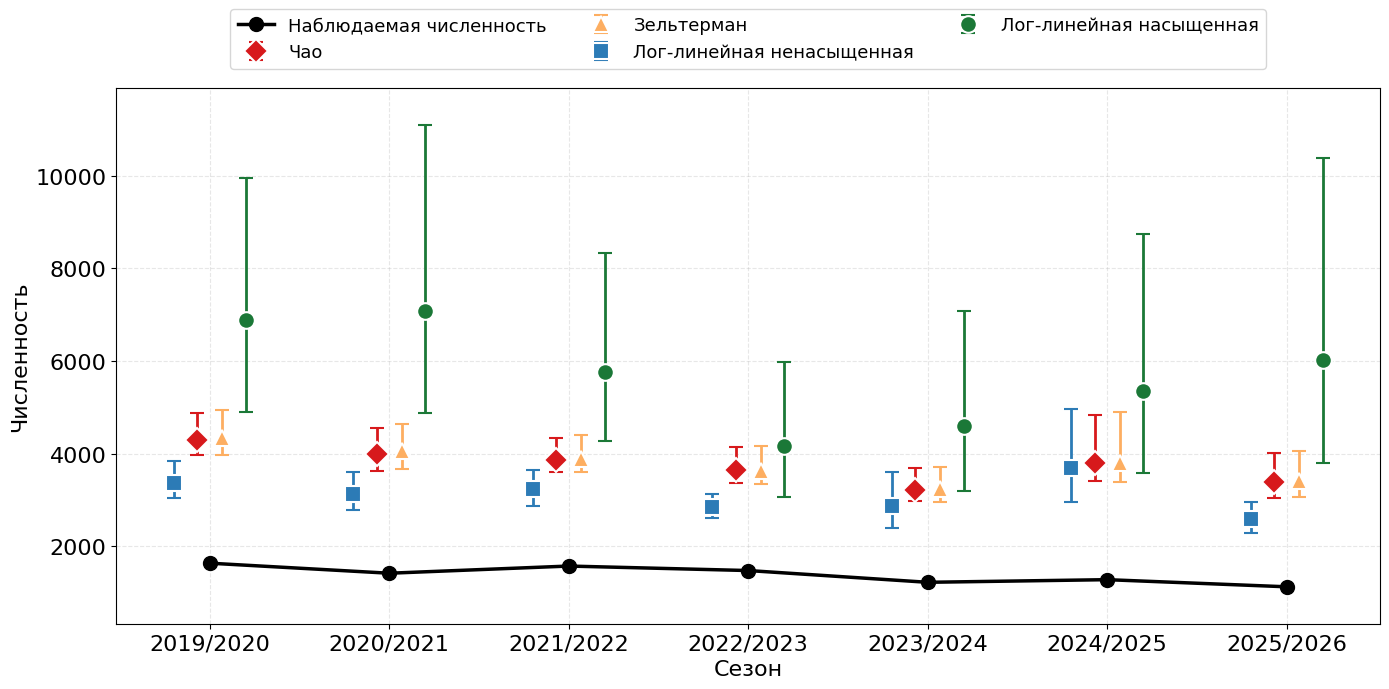

In [14]:
_ = plots.plot_method_comparison(all_estimates, strata="total")

сохранено: pictures\method_comparison_m.png
сохранено: pictures\method_comparison_f.png


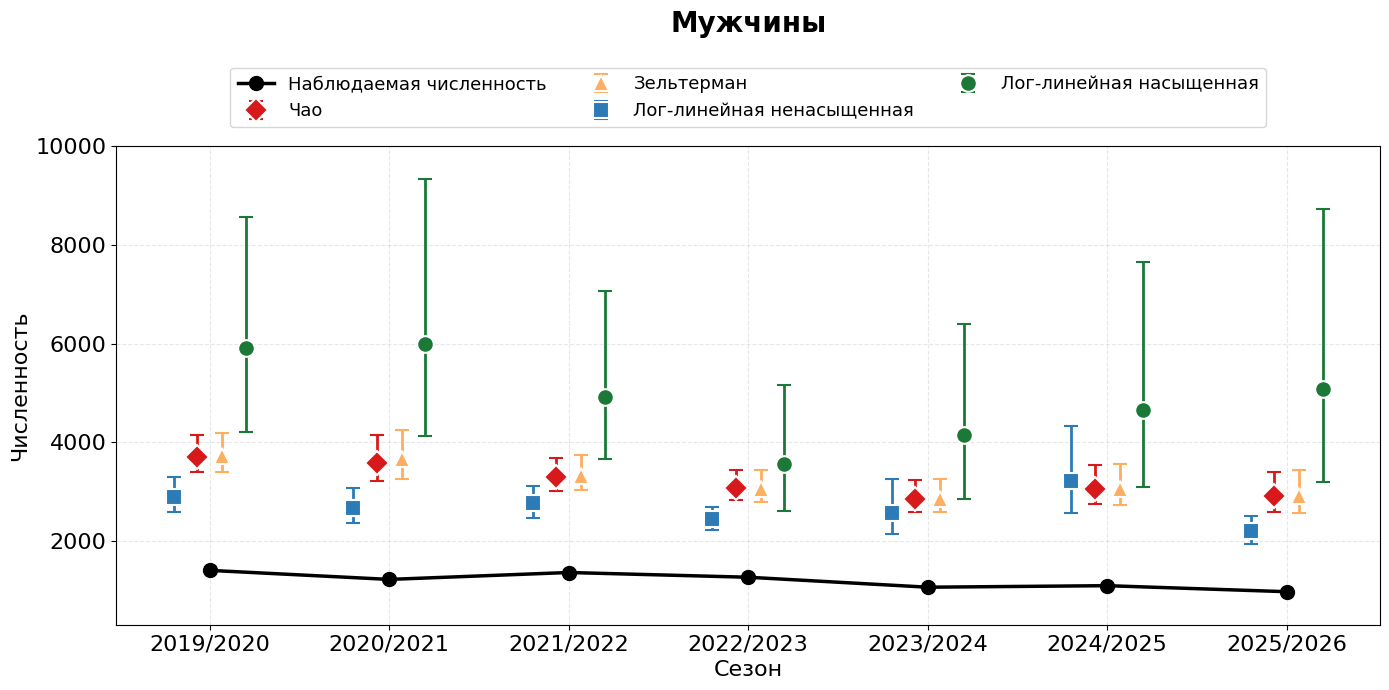

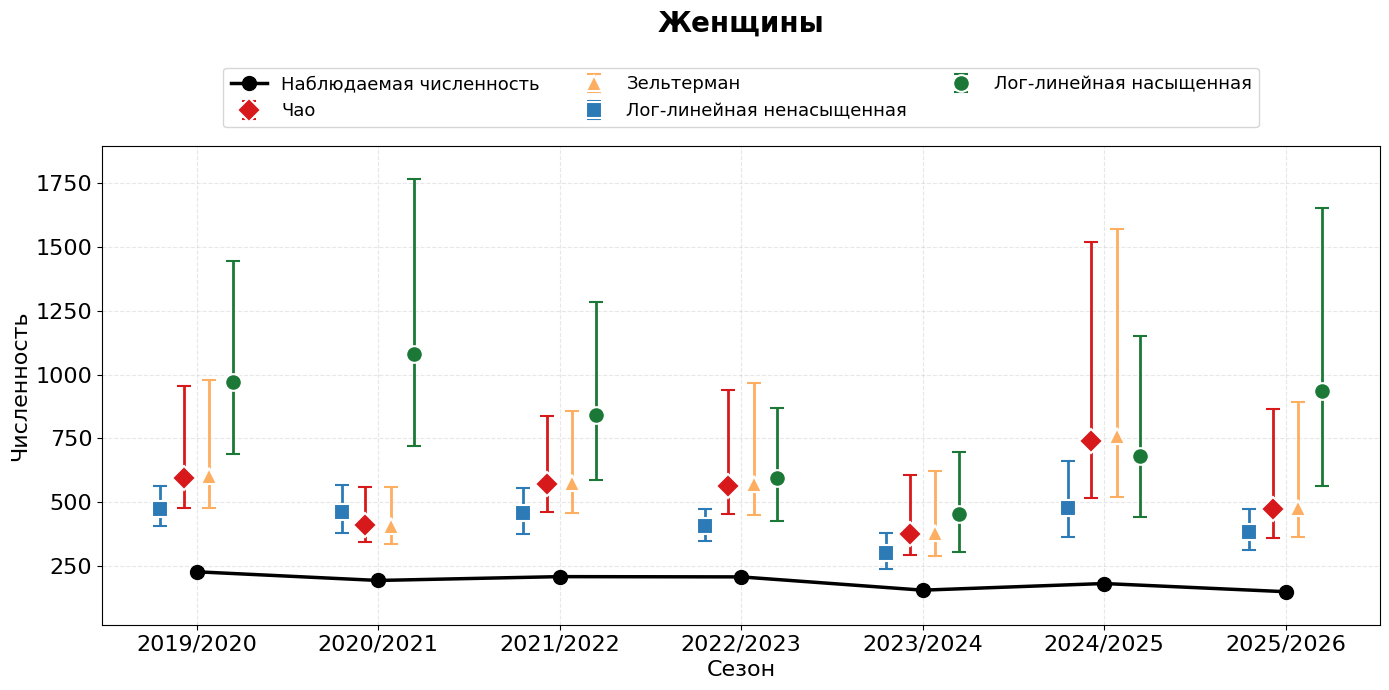

In [15]:
for sex in config.SEX_ORDER:
    _ = plots.plot_method_comparison(
        all_estimates,
        strata=sex,
        filename=f"method_comparison_{'m' if sex == 'Мужчины' else 'f'}.png",
        title=f"{sex}\n\n\n",
    )

сохранено: pictures\final_estimates_by_strata.png


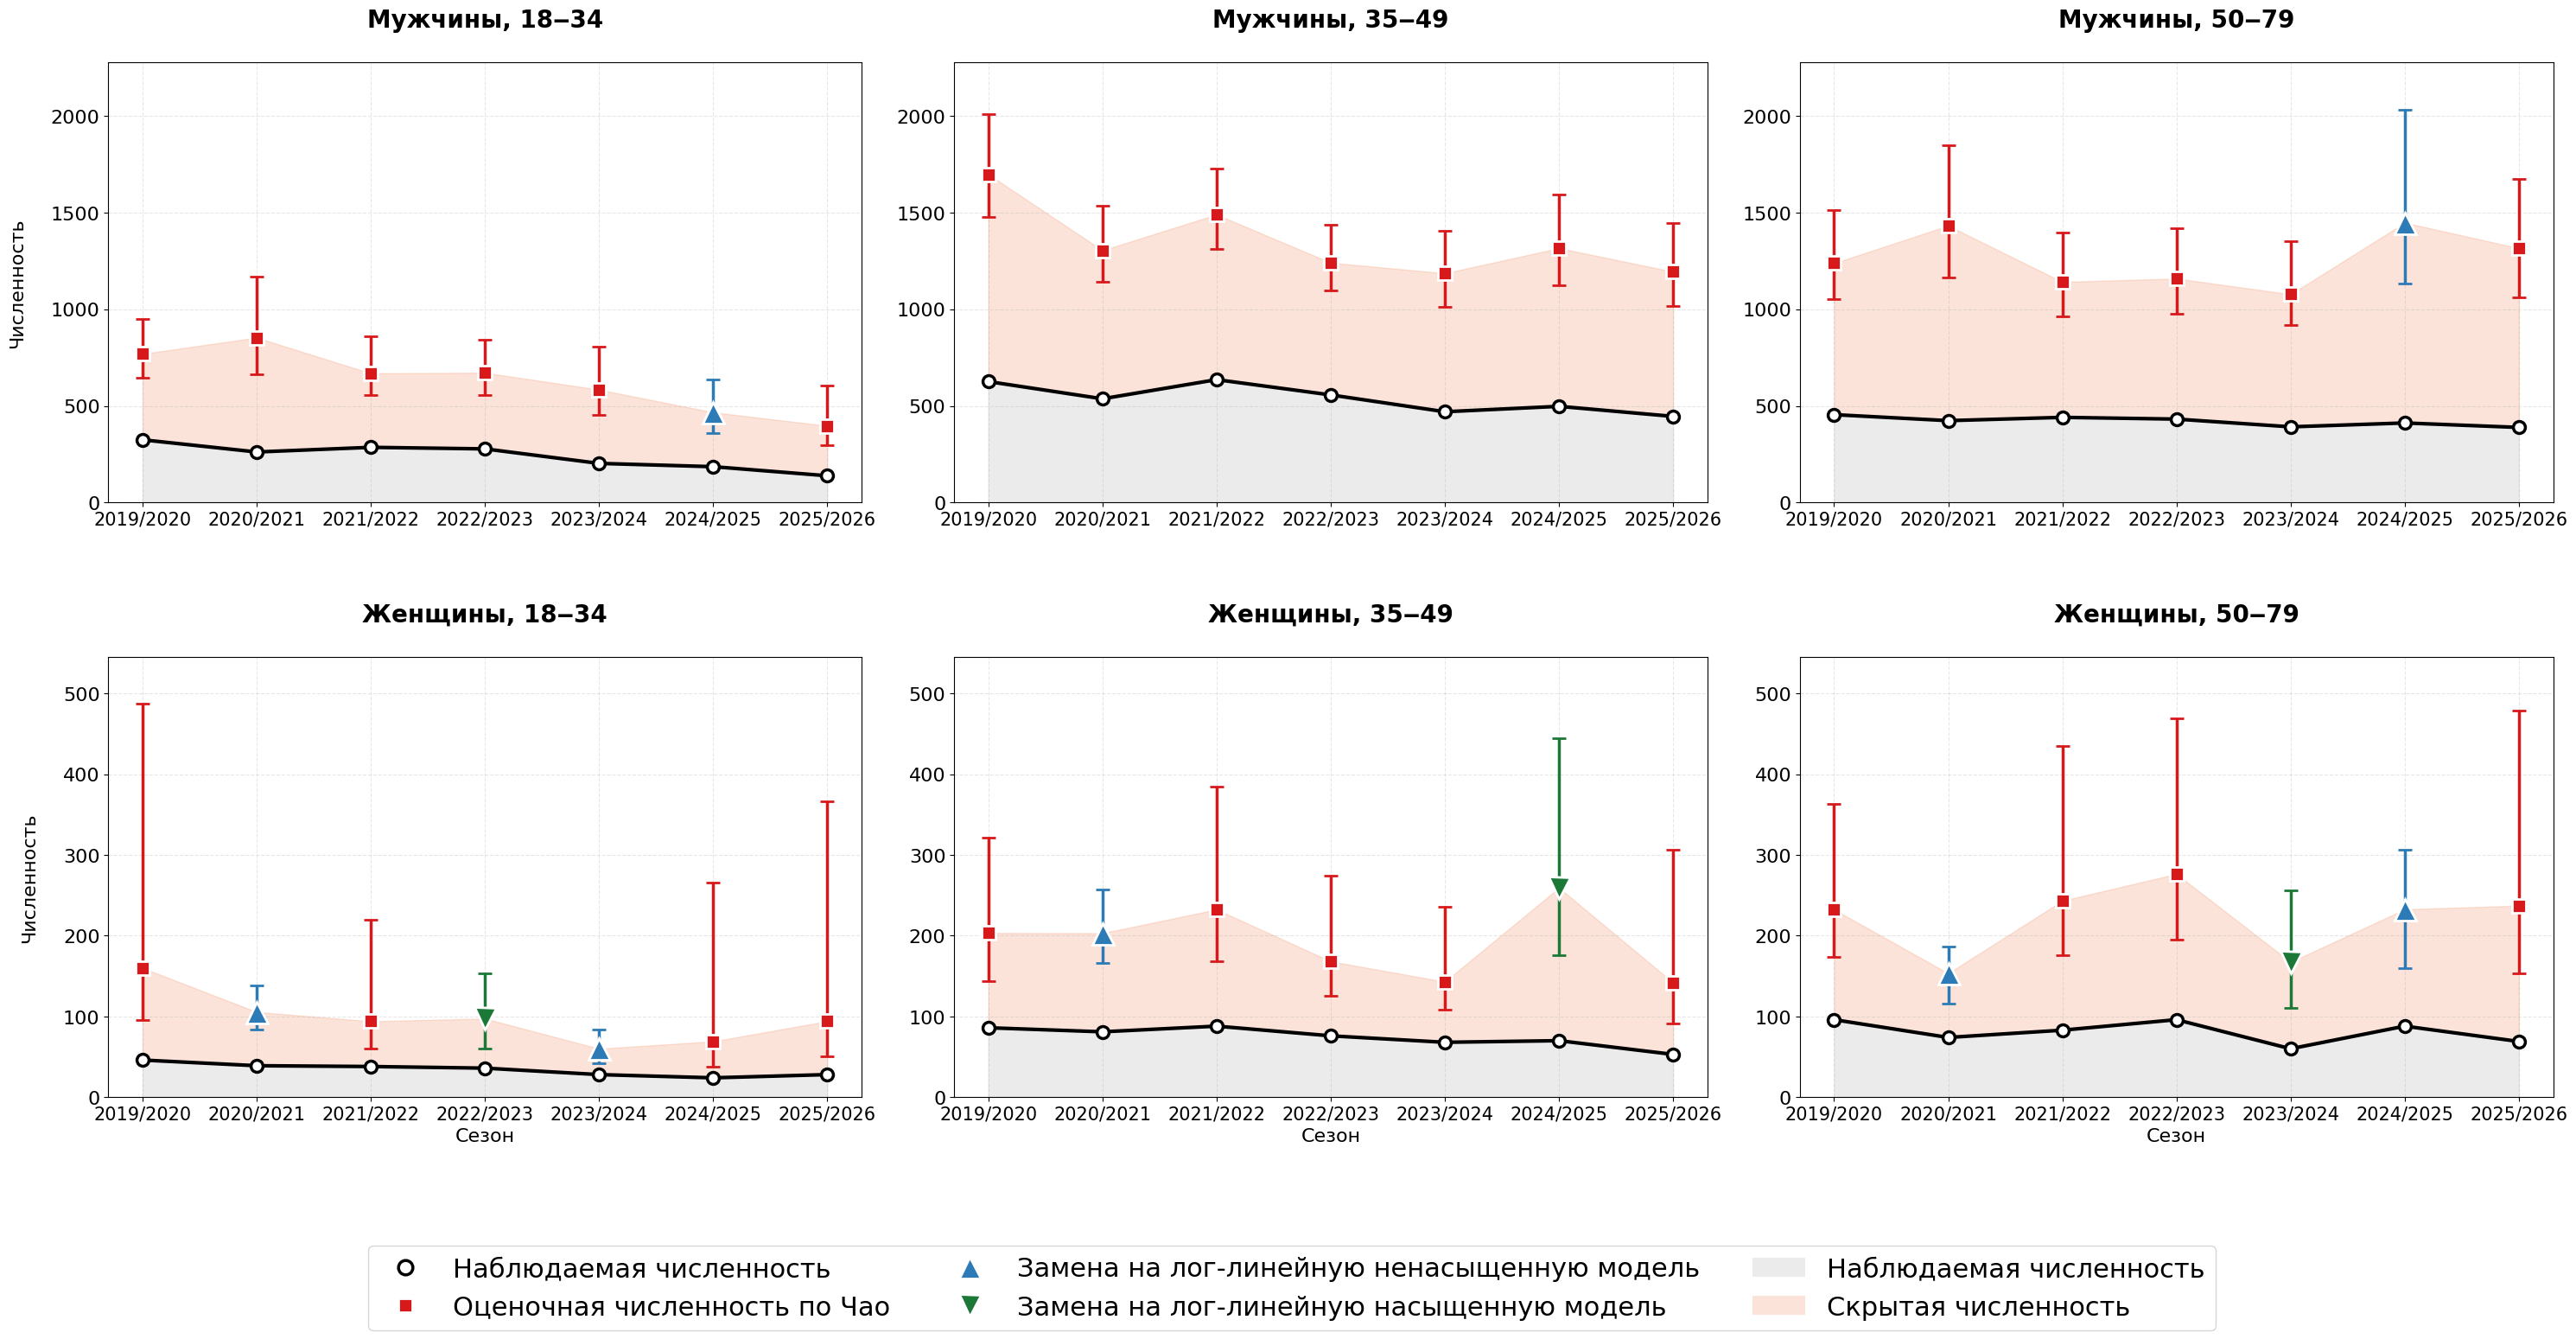

In [33]:
strata_only = df_final[~df_final["strata"].isin(["total"] + config.SEX_ORDER)]
_ = plots.plot_estimates_by_strata(strata_only)